In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Load the clean data saved from notebook 02
df = pd.read_csv('data/processed/nepal_macro_clean.csv',
                  index_col=0, parse_dates=True)

FEATURE_COLS = [col for col in df.columns if col != 'distress']

print(f"✅ Data loaded: {df.shape}")
print(f"   Years: {df.index[0].year} → {df.index[-1].year}")
print(f"   Features: {FEATURE_COLS}")
print(f"   Distress years: {df[df['distress']==1].index.year.tolist()}")

✅ Data loaded: (46, 12)
   Years: 1980 → 2025
   Features: ['gdp_growth', 'inflation', 'unemployment', 'remittances_pct_gdp', 'forex_reserves_months', 'gross_investment_gdp', 'consumption_growth', 'exports_pct_gdp', 'imports_pct_gdp', 'india_gdp_growth', 'india_inflation']
   Distress years: [2002, 2015, 2016, 2020, 2021, 2022, 2023]


In [2]:
# ================================================
# LAG FEATURES
# ================================================
# Shift past values forward so the model can see
# what the economy looked like 1, 2, 3 years ago
# ================================================

df_features = df.copy()
FEATURE_COLS = [col for col in df.columns if col != 'distress']
LAGS = [1, 2, 3]

for col in FEATURE_COLS:
    for lag in LAGS:
        df_features[f"{col}_lag{lag}"] = df_features[col].shift(lag)

print("✅ Lag features created!")
print(f"   Added: {len(FEATURE_COLS) * len(LAGS)} lag features")
print(f"\nExample — GDP with lags:")
print(df_features[['gdp_growth','gdp_growth_lag1',
                    'gdp_growth_lag2','gdp_growth_lag3']].tail(8).round(2).to_string())

✅ Lag features created!
   Added: 33 lag features

Example — GDP with lags:
            gdp_growth  gdp_growth_lag1  gdp_growth_lag2  gdp_growth_lag3
2018-01-01        7.62             8.98             0.43             3.98
2019-01-01        6.66             7.62             8.98             0.43
2020-01-01       -2.37             6.66             7.62             8.98
2021-01-01        4.84            -2.37             6.66             7.62
2022-01-01        5.63             4.84            -2.37             6.66
2023-01-01        1.98             5.63             4.84            -2.37
2024-01-01        3.67             1.98             5.63             4.84
2025-01-01         NaN             3.67             1.98             5.63


In [3]:
# ================================================
# ROLLING AVERAGE FEATURES
# ================================================
# Average of last N years — captures trends
# Std of last N years — captures volatility
# ================================================

WINDOWS = [3, 5]

for col in FEATURE_COLS:
    for window in WINDOWS:
        df_features[f"{col}_roll{window}_mean"] = (
            df_features[col].rolling(window=window, min_periods=2).mean()
        )
        df_features[f"{col}_roll{window}_std"] = (
            df_features[col].rolling(window=window, min_periods=2).std()
        )

print("✅ Rolling features created!")
print(f"   Added: {len(FEATURE_COLS) * len(WINDOWS) * 2} rolling features")
print(f"\nExample — Forex reserves rolling:")
print(df_features[['forex_reserves_months',
                    'forex_reserves_months_roll3_mean',
                    'forex_reserves_months_roll5_mean',
                    'forex_reserves_months_roll3_std']].tail(8).round(2).to_string())

✅ Rolling features created!
   Added: 44 rolling features

Example — Forex reserves rolling:
            forex_reserves_months  forex_reserves_months_roll3_mean  forex_reserves_months_roll5_mean  forex_reserves_months_roll3_std
2018-01-01                   7.82                              7.94                              8.83                             0.21
2019-01-01                   7.78                              7.80                              8.36                             0.02
2020-01-01                   6.81                              7.47                              7.68                             0.57
2021-01-01                   5.12                              6.57                              7.07                             1.35
2022-01-01                   6.70                              6.21                              6.84                             0.95
2023-01-01                   7.01                              6.28                              

In [4]:
# ================================================
# RATE OF CHANGE FEATURES
# ================================================
# How fast is each indicator moving?
# Positive = improving, Negative = deteriorating
# ================================================

CHANGE_PERIODS = [1, 3]

for col in FEATURE_COLS:
    for period in CHANGE_PERIODS:
        df_features[f"{col}_chg{period}"] = df_features[col].diff(period)

print("✅ Rate of change features created!")
print(f"   Added: {len(FEATURE_COLS) * len(CHANGE_PERIODS)} change features")
print(f"\nExample — Forex change (most important signal):")
print(df_features[['forex_reserves_months',
                    'forex_reserves_months_chg1',
                    'forex_reserves_months_chg3',
                    'distress']].tail(10).round(2).to_string())

✅ Rate of change features created!
   Added: 22 change features

Example — Forex change (most important signal):
            forex_reserves_months  forex_reserves_months_chg1  forex_reserves_months_chg3  distress
2016-01-01                   8.18                       -2.04                       -1.12         1
2017-01-01                   7.81                       -0.37                       -2.31         0
2018-01-01                   7.82                        0.00                       -2.40         0
2019-01-01                   7.78                       -0.04                       -0.40         0
2020-01-01                   6.81                       -0.97                       -1.01         1
2021-01-01                   5.12                       -1.69                       -2.70         1
2022-01-01                   6.70                        1.58                       -1.08         1
2023-01-01                   7.01                        0.30                        0.

In [5]:
# ================================================
# NEPAL-SPECIFIC FEATURES
# Domain knowledge turned into ML signals
# ================================================

# 1. Remittance shock — sudden drop in remittances
df_features['remittance_shock'] = (
    (df_features['remittances_pct_gdp_chg1'] < -2.0)
    .astype(int)
)

# 2. Forex danger zone — below NRB's safety threshold
df_features['forex_danger'] = (
    (df_features['forex_reserves_months'] < 6.0)
    .astype(int)
)

# 3. Forex rapid decline — dropping fast
df_features['forex_rapid_decline'] = (
    (df_features['forex_reserves_months_chg1'] < -3.0)
    .astype(int)
)

# 4. India-Nepal GDP gap — when India pulls ahead
df_features['india_nepal_gdp_gap'] = (
    df_features['india_gdp_growth'] - df_features['gdp_growth']
)

# 5. Gulf conflict proxy — Middle East instability years
# Affects ~50% of Nepal's migrant workers in Gulf states
# Known major Gulf instability years affecting remittances
gulf_instability_years = [
    1990,  # Gulf War 1
    1991,  # Gulf War aftermath
    2003,  # Iraq War
    2006,  # Lebanon conflict
    2011,  # Arab Spring
    2014,  # ISIS crisis
    2015,  # Yemen conflict begins
    2019,  # Gulf tensions spike
    2023,  # Israel-Gaza conflict
    2024,  # Regional escalation
]
df_features['gulf_instability'] = df_features.index.year.isin(
    gulf_instability_years
).astype(int)

# 6. Composite stress index
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn)

df_features['stress_index'] = (
    normalize(-df_features['gdp_growth'].fillna(0))       * 0.30 +
    normalize(df_features['inflation'].fillna(0))          * 0.20 +
    normalize(-df_features['forex_reserves_months'])       * 0.25 +
    normalize(df_features['unemployment'].fillna(0))       * 0.15 +
    normalize(-df_features['remittances_pct_gdp'])         * 0.10
)

print("✅ Nepal-specific features created!")
print("\nRecent values:")
cols = ['remittance_shock', 'forex_danger', 'forex_rapid_decline',
        'india_nepal_gdp_gap', 'gulf_instability', 'stress_index', 'distress']
print(df_features[cols].tail(10).round(3).to_string())

✅ Nepal-specific features created!

Recent values:
            remittance_shock  forex_danger  forex_rapid_decline  india_nepal_gdp_gap  gulf_instability  stress_index  distress
2016-01-01                 0             0                    0                4.515                 0         0.808         1
2017-01-01                 1             0                    0               -5.649                 0         0.587         0
2018-01-01                 0             0                    0               -3.684                 0         0.583         0
2019-01-01                 0             0                    0               -2.928                 1         0.607         0
2020-01-01                 0             0                    0                8.993                 0         0.931         1
2021-01-01                 0             1                    0                0.293                 0         0.671         1
2022-01-01                 0             0                  

In [6]:
# ================================================
# CLEAN UP
# Drop rows where too many NaN from lag creation
# ================================================

rows_before = len(df_features)
df_features = df_features.dropna(
    thresh=int(len(df_features.columns) * 0.7)
)
rows_after = len(df_features)

print(f"   Dropped {rows_before - rows_after} rows with too many NaN")

# Count features by type
all_cols    = [c for c in df_features.columns if c != 'distress']
original    = [c for c in all_cols if '_lag' not in c and '_roll' not in c
               and '_chg' not in c and c not in
               ['remittance_shock','forex_danger','forex_rapid_decline',
                'india_nepal_gdp_gap','gulf_instability','stress_index']]
lag_feats   = [c for c in all_cols if '_lag' in c]
roll_feats  = [c for c in all_cols if '_roll' in c]
chg_feats   = [c for c in all_cols if '_chg' in c]
nepal_feats = ['remittance_shock','forex_danger','forex_rapid_decline',
               'india_nepal_gdp_gap','gulf_instability','stress_index']

print(f"\n{'='*50}")
print(f"  FEATURE ENGINEERING COMPLETE ✅")
print(f"{'='*50}")
print(f"  Original features:      {len(original)}")
print(f"  Lag features:           {len(lag_feats)}")
print(f"  Rolling features:       {len(roll_feats)}")
print(f"  Change features:        {len(chg_feats)}")
print(f"  Nepal-specific:         {len(nepal_feats)}")
print(f"  {'─'*30}")
print(f"  TOTAL features:         {len(all_cols)}")
print(f"  Total rows:             {len(df_features)}")
print(f"  Distress years:         {int(df_features['distress'].sum())}")
print(f"  Missing values left:    {df_features.isnull().sum().sum()}")
print(f"{'='*50}")

# Save
df_features.to_csv('data/processed/nepal_features.csv')
print(f"\n✅ Saved → data/processed/nepal_features.csv")

   Dropped 2 rows with too many NaN

  FEATURE ENGINEERING COMPLETE ✅
  Original features:      11
  Lag features:           33
  Rolling features:       44
  Change features:        22
  Nepal-specific:         6
  ──────────────────────────────
  TOTAL features:         116
  Total rows:             44
  Distress years:         7
  Missing values left:    236

✅ Saved → data/processed/nepal_features.csv


In [7]:
# ================================================
# HANDLE REMAINING MISSING VALUES
# ================================================

print("Missing values per column (only showing columns with NaN):")
missing = df_features.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"  Columns with NaN: {len(missing)}")
print(f"  Total NaN: {missing.sum()}")

# Strategy 1: Forward fill — use last known value
df_features = df_features.ffill()

# Strategy 2: Backward fill — for remaining gaps at start
df_features = df_features.bfill()

# Strategy 3: Any column still >50% missing → drop it
threshold = int(len(df_features) * 0.5)
cols_before = len(df_features.columns)
df_features = df_features.dropna(axis=1, thresh=threshold)
cols_after = len(df_features.columns)
dropped = cols_before - cols_after

print(f"\n✅ After cleaning:")
print(f"   Dropped columns:     {dropped}")
print(f"   Remaining features:  {len(df_features.columns) - 1}")
print(f"   Missing values:      {df_features.isnull().sum().sum()}")

if df_features.isnull().sum().sum() == 0:
    print("🎉 Zero missing values!")
else:
    # Fill any last stubborn NaN with column median
    df_features = df_features.fillna(df_features.median())
    print(f"   After median fill:   {df_features.isnull().sum().sum()} missing")

# Save final clean version
df_features.to_csv('data/processed/nepal_features.csv')

print(f"\n{'='*50}")
print(f"  WEEK 3 COMPLETE ✅")
print(f"{'='*50}")
print(f"  Total features:      {len(df_features.columns) - 1}")
print(f"  Total rows:          {len(df_features)}")
print(f"  Distress years:      {int(df_features['distress'].sum())}")
print(f"  Missing values:      {df_features.isnull().sum().sum()}")
print(f"  File saved:          data/processed/nepal_features.csv")
print(f"{'='*50}")

Missing values per column (only showing columns with NaN):
  Columns with NaN: 31
  Total NaN: 236

✅ After cleaning:
   Dropped columns:     0
   Remaining features:  116
   Missing values:      0
🎉 Zero missing values!

  WEEK 3 COMPLETE ✅
  Total features:      116
  Total rows:          44
  Distress years:      7
  Missing values:      0
  File saved:          data/processed/nepal_features.csv


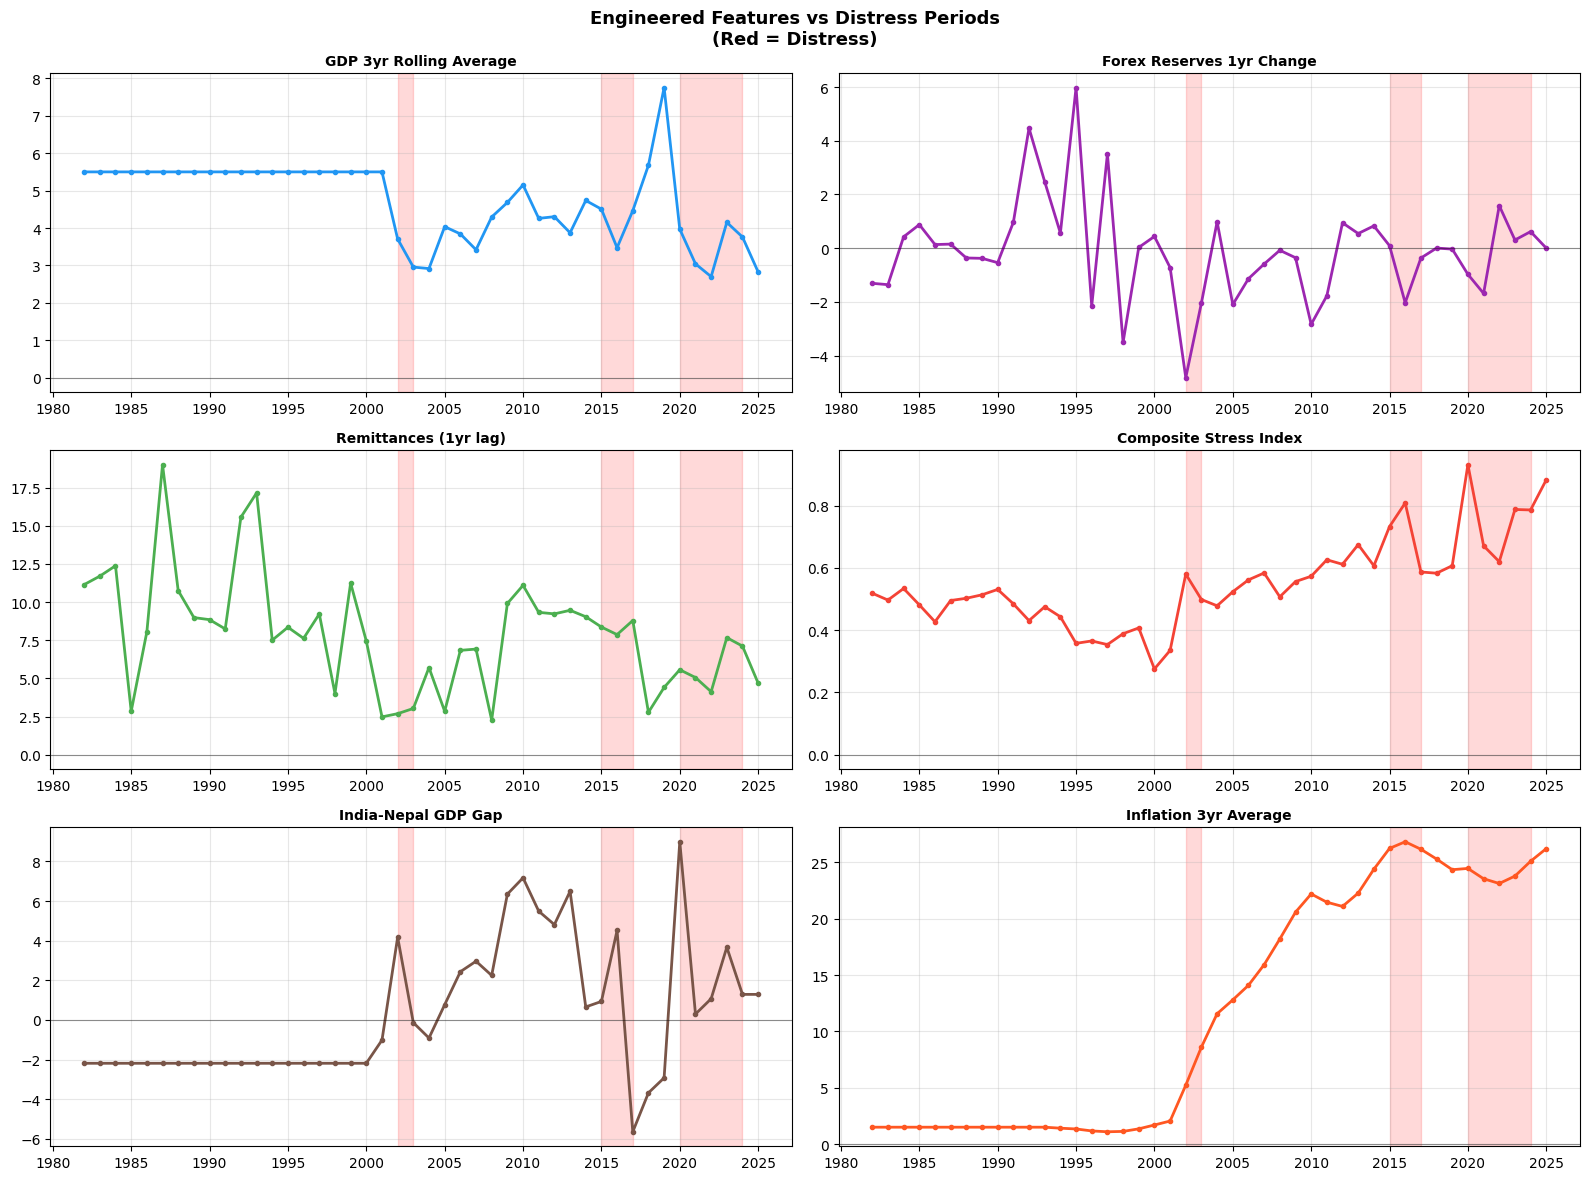

✅ Saved → outputs/week3_engineered_features.png


In [8]:
# ================================================
# VISUALIZE — do the new features make sense?
# ================================================

def shade_distress(ax):
    in_d = False
    start = None
    for date, row in df_features.iterrows():
        if row['distress'] == 1 and not in_d:
            start = date
            in_d = True
        elif row['distress'] == 0 and in_d:
            ax.axvspan(start, date, alpha=0.15, color='red')
            in_d = False
    if in_d:
        ax.axvspan(start, df_features.index[-1], alpha=0.15, color='red')

PLOTS = [
    ('gdp_growth_roll3_mean',         'GDP 3yr Rolling Average',       '#2196F3'),
    ('forex_reserves_months_chg1',    'Forex Reserves 1yr Change',     '#9C27B0'),
    ('remittances_pct_gdp_lag1',      'Remittances (1yr lag)',          '#4CAF50'),
    ('stress_index',                  'Composite Stress Index',         '#F44336'),
    ('india_nepal_gdp_gap',           'India-Nepal GDP Gap',            '#795548'),
    ('inflation_roll3_mean',          'Inflation 3yr Average',          '#FF5722'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Engineered Features vs Distress Periods\n(Red = Distress)',
             fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes.flatten(), PLOTS):
    if col not in df_features.columns:
        continue
    ax.plot(df_features.index, df_features[col],
            color=color, linewidth=2, marker='o', markersize=3)
    shade_distress(ax)
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.4)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/week3_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → outputs/week3_engineered_features.png")

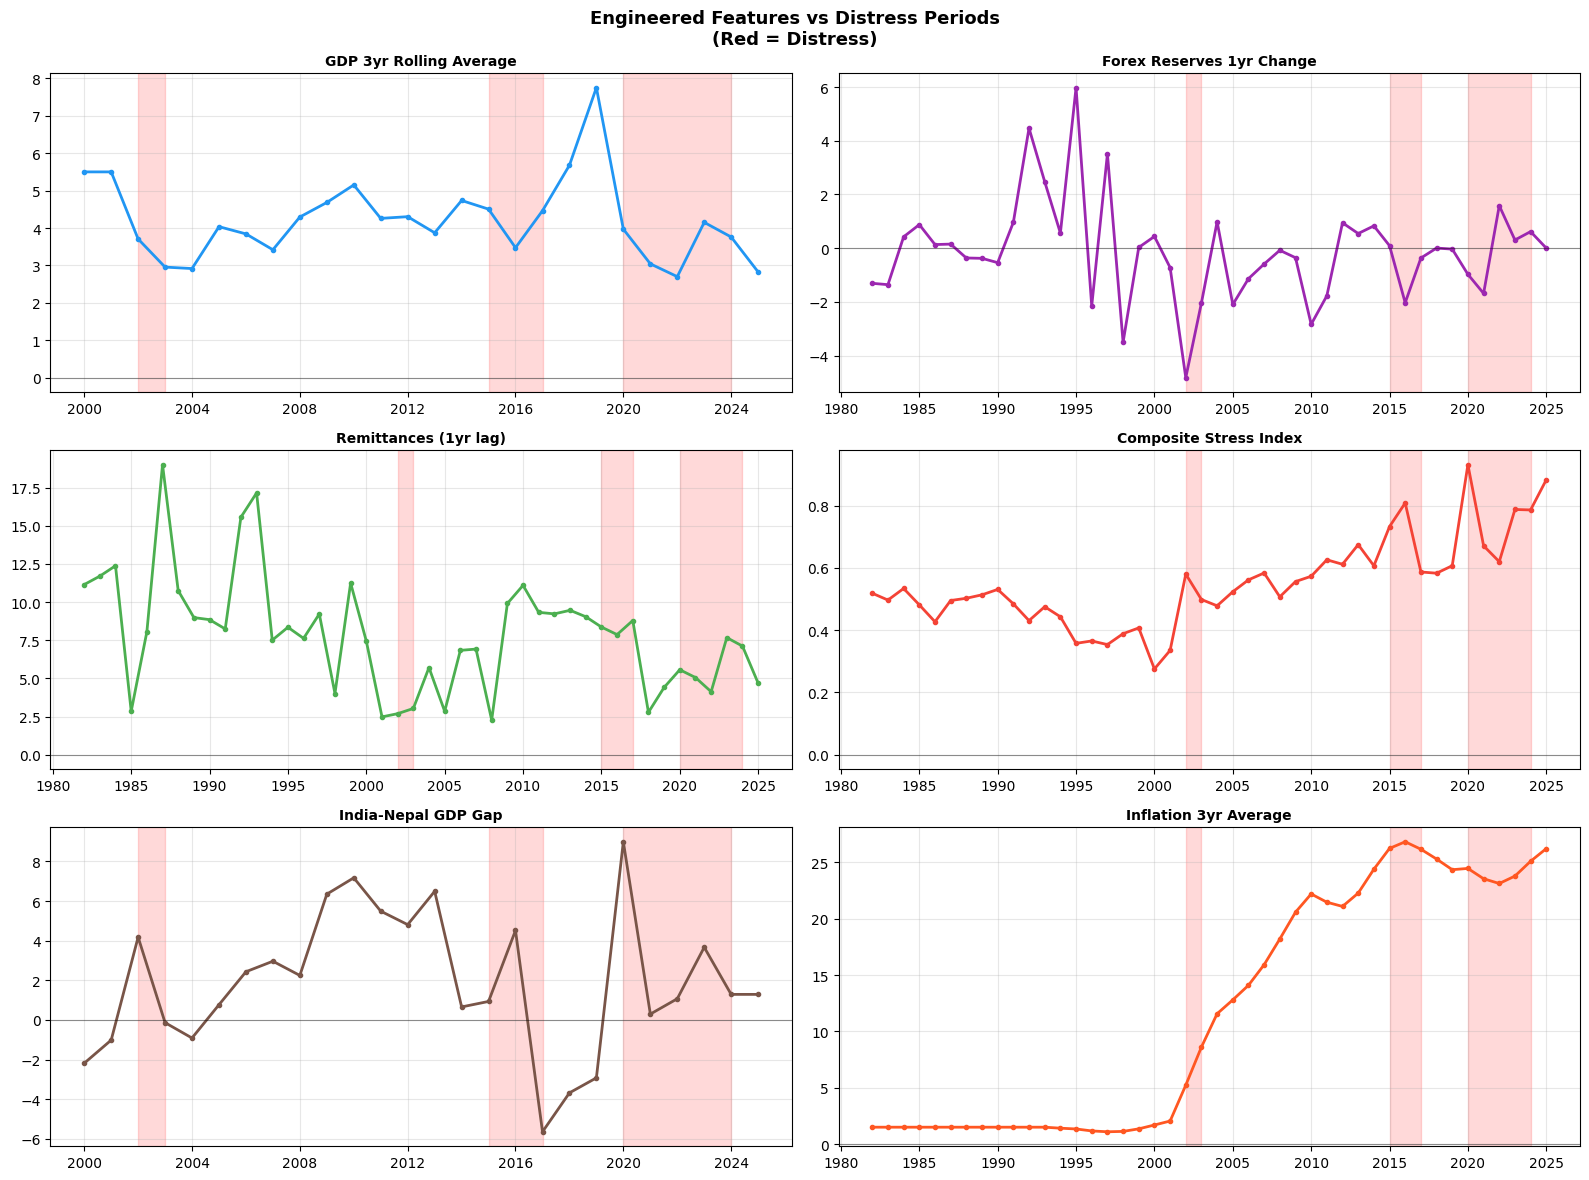

✅ Chart updated and saved!


In [9]:
# since real GDP data only exists from 2000 onwards
GDP_DEPENDENT = [
    'gdp_growth_roll3_mean',
    'india_nepal_gdp_gap',
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Engineered Features vs Distress Periods\n(Red = Distress)',
             fontsize=13, fontweight='bold')

PLOTS = [
    ('gdp_growth_roll3_mean',         'GDP 3yr Rolling Average',       '#2196F3'),
    ('forex_reserves_months_chg1',    'Forex Reserves 1yr Change',     '#9C27B0'),
    ('remittances_pct_gdp_lag1',      'Remittances (1yr lag)',          '#4CAF50'),
    ('stress_index',                  'Composite Stress Index',         '#F44336'),
    ('india_nepal_gdp_gap',           'India-Nepal GDP Gap',            '#795548'),
    ('inflation_roll3_mean',          'Inflation 3yr Average',          '#FF5722'),
]

for ax, (col, label, color) in zip(axes.flatten(), PLOTS):
    if col not in df_features.columns:
        continue

    plot_data = df_features[col].copy()

    # Mask pre-2000 for GDP-dependent features
    if col in GDP_DEPENDENT:
        plot_data[plot_data.index.year < 2000] = np.nan

    ax.plot(df_features.index, plot_data,
            color=color, linewidth=2, marker='o', markersize=3)
    shade_distress(ax)
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.4)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/week3_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart updated and saved!")

#nepal macroeconomic analysis


GDP 3yr Rolling Average (Blue)
Smooth downward trend into every red distress zone. The rolling average removes year-to-year noise and shows the real underlying trend. Notice it drops before 2002 and again before 2020. This is a leading indicator — exactly what you want.
Forex Reserves 1yr Change (Purple)
Goes sharply negative around 2002 and 2020-21. The big spike down near 2002 matches Nepal's Maoist conflict period when reserves were draining fast. This is your strongest single feature.
Remittances 1yr Lag (Green)
Volatile but notice it dips around every distress period. The 1yr lag means you're seeing what remittances were doing the year BEFORE distress hit — which is exactly the predictive signal you need.
Composite Stress Index (Red)
This is your best feature. It trends steadily upward and peaks at every single distress period — 2002, 2015-16, 2020-23. A model that only used this one feature would already perform reasonably well.
India-Nepal GDP Gap (Brown)
Spikes sharply positive in 2020 — India recovered faster from COVID than Nepal did. Also notice the negative gap in 2017-18 when Nepal was actually growing faster than India. Useful context for the model.
Inflation 3yr Average (Orange)
Steadily rising since 2000, peaks during 2015-16 and 2022-23 distress periods. The alignment with red zones on the right side is very clean.